### Load Libraries & Dataset

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
import joblib

In [90]:
df = pd.read_csv(r'D:\Local\Mix\NTI-ML\NTI-Projects\Lifestyle Data for Regression\data\insurance.csv')

### Explore data 

In [91]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


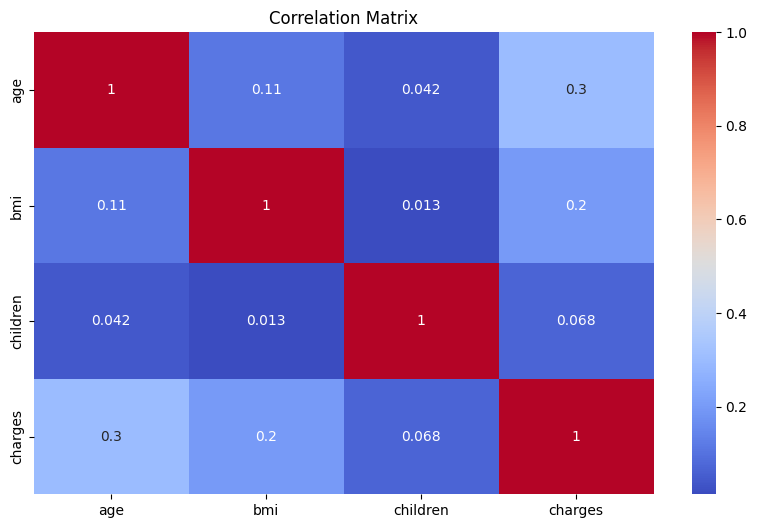

In [93]:
# Plot to explore coorrelations between features and target variable
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [94]:
df.duplicated().sum()

1

### Cleaning & Feature Engenniring

In [95]:
# cleaning the data by removing duplicates
df = df.drop_duplicates()
# cleaning the data by handling missing values
df = df.dropna()

In [96]:
# Feature Engineering : bmi_category
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, float('inf')], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
# Feature Engineering : is_obese
df['is_obese'] = (df['bmi'] >= 30).astype(int)
# Feature Engineering : smoker_bmi_interaction
df['smoker_bmi_interaction'] = df['smoker'].map({'yes': 1, 'no': 0}) * df['bmi']
# Feature Engineering : (Age-Smoker Interaction
df['age_smoker_interaction'] = df['age'] * df['smoker'].map({'yes': 1, 'no': 0})
# Feature Engineering : Age Groups
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, float('inf')], labels=['0-18', '19-30', '31-45', '46-60', '60+'])
# Feature Engineering : binary encoding for categorical variables
df["smoker_encoded"] = df["smoker"].map({"yes": 1, "no": 0})
df["sex_encoded"] = df["sex"].map({"female": 1, "male": 0})
# Feature Engineering : One-hot encoding for region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [97]:
# one-hot encoding
df = pd.get_dummies(df, columns=["age_group"], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=["bmi_category"], drop_first=True, dtype=int)
# drop un effected coulomns
df = df.drop(columns=["smoker", "sex"], errors="ignore")

df[['region_southwest', 'region_southeast', 'region_northwest']] = df[['region_southwest', 'region_southeast', 'region_northwest']].astype(int)

In [98]:
df.head()

,age,bmi,children,charges,is_obese,smoker_bmi_interaction,age_smoker_interaction,smoker_encoded,sex_encoded,region_northwest,region_southeast,region_southwest,age_group_19-30,age_group_31-45,age_group_46-60,age_group_60+,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,27.900,0,16884.92400,0,27.9,19,1,1,0,0,1,1,0,0,0,0,1,0
1,18,33.770,1,1725.55230,1,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,28,33.000,3,4449.46200,1,0.0,0,0,0,0,1,0,1,0,0,0,0,0,1
3,33,22.705,0,21984.47061,0,0.0,0,0,0,1,0,0,0,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,0.0,0,0,0,1,0,0,0,1,0,0,0,1,0


### Scale & Train

In [99]:
# Split data to train
X = df.drop(columns=["charges"])
y = df['charges']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [101]:
# Standard Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Predection & Evaluation

In [102]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluation
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print("===== Train =====")
print("R²   :", train_r2)
print("MAE  :", train_mae)
print("RMSE :", train_rmse)

print("\n===== Test =====")
print("R²   :", test_r2)
print("MAE  :", test_mae)
print("RMSE :", test_rmse)

===== Train =====
R²   : 0.8352460188858762
MAE  : 2829.6804407186546
RMSE : 4749.445965076567

===== Test =====
R²   : 0.8856183451665611
MAE  : 2845.1599574150655
RMSE : 4584.5744285266355


### Save Model

In [103]:
# Save Model
joblib.dump(model, "linear_regression_model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.


### Predection

In [104]:
# Load Model
model = joblib.load("linear_regression_model.pkl")

# Load Scaler
scaler = joblib.load("scaler.pkl")

In [105]:
def prepare_input(age, sex, bmi, children, smoker, region):

    data = {}

    # Basic Features
    data["age"] = age
    data["bmi"] = bmi
    data["children"] = children

    # Encoding
    data["smoker_encoded"] = 1 if smoker.lower() == "yes" else 0
    data["sex_encoded"] = 1 if sex.lower() == "male" else 0

    # Feature Engineering
    data["is_obese"] = 1 if bmi >= 30 else 0
    data["smoker_bmi_interaction"] = data["smoker_encoded"] * bmi
    data["age_smoker_interaction"] = data["smoker_encoded"] * age

    # Region
    data["region_northwest"] = 1 if region == "northwest" else 0
    data["region_southeast"] = 1 if region == "southeast" else 0
    data["region_southwest"] = 1 if region == "southwest" else 0

    # Age Groups
    data["age_group_19-30"] = 1 if 19 <= age <= 30 else 0
    data["age_group_31-45"] = 1 if 31 <= age <= 45 else 0
    data["age_group_46-60"] = 1 if 46 <= age <= 60 else 0
    data["age_group_60+"] = 1 if age > 60 else 0

    # BMI Categories
    data["bmi_category_Normal"] = 1 if 18.5 <= bmi < 25 else 0
    data["bmi_category_Overweight"] = 1 if 25 <= bmi < 30 else 0
    data["bmi_category_Obese"] = 1 if bmi >= 30 else 0

    columns = [
        'age', 'bmi', 'children', 'is_obese',
        'smoker_bmi_interaction', 'age_smoker_interaction',
        'smoker_encoded', 'sex_encoded',
        'region_northwest', 'region_southeast', 'region_southwest',
        'age_group_19-30', 'age_group_31-45',
        'age_group_46-60', 'age_group_60+',
        'bmi_category_Normal',
        'bmi_category_Overweight',
        'bmi_category_Obese'
    ]

    return pd.DataFrame([data])[columns]

In [106]:
input_df = prepare_input(
    age=25,
    sex="male",
    bmi=31.5,
    children=2,
    smoker="yes",
    region="southeast"
)

input_scaled = scaler.transform(input_df)

prediction = model.predict(input_scaled)

print(prediction[0])

32314.96494710732
